In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib  inline


In [12]:
df = pd.read_csv("/Users/madhavathavale/Library/Mobile Documents/com~apple~CloudDocs/workspace/python/Krish-Naik-complete-Data-Science/3-Complete Linear Regression/Practicals/height-weight.csv")


In [13]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0.5, 1.0, 'Weight vs Height ')

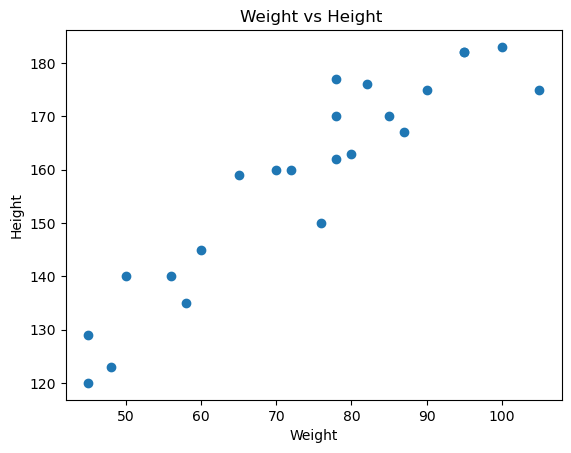

In [21]:
#scatter plot
plt.scatter(df['Weight'],df['Height'])
plt.ylabel('Height')
plt.xlabel('Weight')
plt.title('Weight vs Height ')

In [22]:
#correlation
df.corr()   


,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


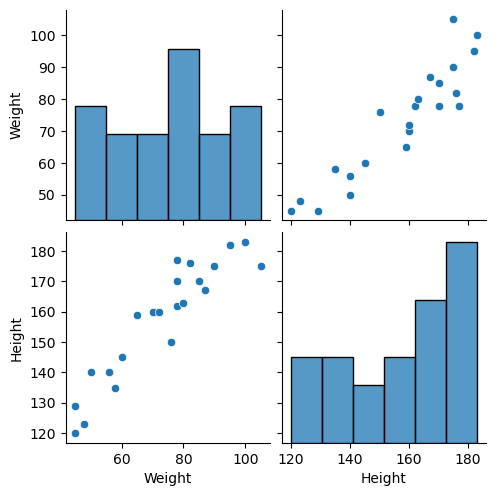

In [23]:
import seaborn as sns
sns.pairplot(df)

In [ ]:
X= df[['Weight']] # Needs to be a dataframe
y= df['Height']  # needs to be a series or 1 -D array


In [27]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [29]:
X_train.shape



(17, 1)

In [31]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [32]:
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)   # we are not fitting the test data  because we have already fitted the train data

In [33]:
X_train

array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

In [36]:
from sklearn.linear_model import LinearRegression


In [37]:
regression = LinearRegression()

In [38]:
regression.fit(X_train,y_train)

LinearRegression()

In [39]:
print("coeffcient : ",regression.coef_)
print("Intercept : ",regression.intercept_)
print("R^2 : ",regression.score(X_train,y_train))

coeffcient :  [17.2982057]
Intercept :  156.47058823529412
R^2 :  0.9208287444697436


Text(0, 0.5, 'Height')

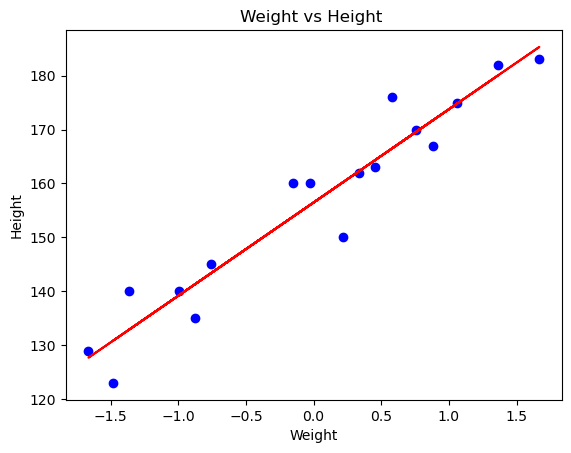

In [40]:
plt.scatter(X_train,y_train,color='blue')
plt.plot(X_train,regression.predict(X_train),color='red')
plt.title('Weight vs Height ')
plt.xlabel('Weight')
plt.ylabel('Height')

In [41]:
y_pred = regression.predict(X_test)


In [44]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
print("Mean Squared Error : ",mean_squared_error(y_test,y_pred))
print("Mean Absolute Error : ",mean_absolute_error(y_test,y_pred))  
print("RMSE " , np.sqrt(mean_squared_error(y_test,y_pred)))

Mean Squared Error :  114.84069295228699
Mean Absolute Error :  9.665125886795005
RMSE  10.716374991212605


R Square

R^2= 1 - (SSR/SST)

Adjusted R2 = 1 - [(1-R2)*(n-1)(n-k-1)]

n : number of observations

k: number of predictor variables

In [49]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
print("R^2 : ",score)

R^2 :  0.7360826717981276


In [50]:
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)   # Adjusted R^2

0.6701033397476595

In [51]:
#OLS linear  regression
import statsmodels.api as sm

In [52]:
model = sm.OLS(y_train,X_train).fit()

In [53]:
prediction = model.predict(X_test)


In [54]:
print(prediction    )

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [56]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Thu, 13 Mar 2025   Prob (F-statistic):                       0.664
Time:                        17:04:16   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

/Users/madhavathavale/opt/anaconda3/lib/python3.9/site-packages/scipy/stats/_stats_py.py:1769: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=17
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [59]:
# prediction for new data
new_data = pd.DataFrame(data=[72],columns=['Weight'])

In [60]:
new_data

,Weight
0,72


In [61]:
new_data = sc.transform(new_data)

In [63]:
regression.predict(new_data)

array([155.97744705])